# **Phase 1: Data Collection and Exploratory Data Analysis (EDA)**

### **Step 1 - Data Import and Preprocessing**

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/Food_Delivery_Time_Prediction.csv")

df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [4]:
df.shape

(200, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

**Check for any missing or inconsistent values**

In [6]:
df.isnull().sum()

,0
Order_ID,0
Customer_Location,0
Restaurant_Location,0
Distance,0
Weather_Conditions,0
Traffic_Conditions,0
Delivery_Person_Experience,0
Order_Priority,0
Order_Time,0
Vehicle_Type,0


*No missing values but assume if found we delete it with*
df.dropna()

*We fill it with Mean/Mode* : df["Distance"].fillna(df["Distance"].mean())

## **Data Transformation**

### Encode Categorical Variables:

**1. Label Encoding : (apply where we can categorize the values like low,high,medium etc.)**

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le = LabelEncoder()
df["Traffic_Conditions"] = le.fit_transform(df["Traffic_Conditions"])

In [9]:
df["Traffic_Conditions"].head()

,Traffic_Conditions
0,2
1,2
2,2
3,1
4,0


**2. One-Hot Encoding: (the strings that cant be categorized)**

OR we can perform it on multiple colums together

In [10]:
df = pd.get_dummies(df, columns=["Weather_Conditions", "Vehicle_Type"])

In [11]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,2,4,Medium,Afternoon,4.1,3.0,26.22,1321.10,81.54,False,True,False,False,False,False,True
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,2,8,Low,Night,4.5,4.2,62.61,152.21,29.02,True,False,False,False,False,False,True
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,2,9,High,Night,3.3,3.4,48.43,1644.38,64.17,False,False,True,False,False,True,False
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,1,2,Medium,Evening,3.2,3.7,111.63,541.25,79.23,True,False,False,False,False,True,False
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,0,6,Low,Night,3.5,2.8,32.38,619.81,2.34,False,True,False,False,False,True,False


### Normalize/Standardize Numeric Columns

**Standardization**: Centers data around mean.

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

df[["Distance","Delivery_Time","Order_Cost"]] = scaler.fit_transform(df[["Distance","Delivery_Time","Order_Cost"]])

#we can do any of Normalization or Standardization

**Normalization** :Converts values between  0 and 1

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
""" scaler = MinMaxScaler()

df["Distance"] = scaler.fit_transform(df[["Distance"]]) """

' scaler = MinMaxScaler()\n\ndf["Distance"] = scaler.fit_transform(df[["Distance"]]) '

In [19]:
df[["Distance","Delivery_Time","Order_Cost"]].head()

,Distance,Delivery_Time,Order_Cost
0,-1.454738,-1.487932,0.501852
1,1.439192,-0.264987,-1.634294
2,-0.666417,-0.741529,1.092646
3,0.335835,1.382411,-0.923323
4,-0.700119,-1.280915,-0.779755


## **Step 2 - Exploratory Data Analysis (EDA)**

**1. Descriptive Statistics** :
Calculate the basic statistics for numerical features such as mean, median, mode, and variance

In [20]:
df.describe()

,Distance,Traffic_Conditions,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
count,2.000000e+02,200.000000,200.000000,200.000000,200.000000,2.000000e+02,2.000000e+02,200.000000
mean,-1.643130e-16,1.085000,5.250000,3.738500,3.686500,3.730349e-16,-2.042810e-16,46.616650
std,1.002509e+00,0.768589,2.745027,0.703021,0.697063,1.002509e+00,1.002509e+00,29.361706
min,-1.608593e+00,0.000000,1.000000,2.500000,2.600000,-1.857269e+00,-1.688954e+00,1.240000
25%,-7.924313e-01,0.000000,3.000000,3.200000,3.100000,-7.896704e-01,-9.013569e-01,21.602500
50%,-1.806765e-01,1.000000,5.000000,3.800000,3.700000,7.662482e-02,-1.925947e-02,47.530000
75%,7.325599e-01,2.000000,8.000000,4.300000,4.300000,8.789834e-01,9.076026e-01,70.245000
max,1.963762e+00,2.000000,10.000000,5.000000,5.000000,1.652608e+00,1.737826e+00,99.740000


**2. Correlation Analysis** :
Visualize correlations between features and the target variable (Delivery_Time) to identify the most relevant predictors.


Correlation measures relationship between two variables.

**Range: *-1 to +1***

**+1** : Perfect positive relation

Example: *More Distance → More Delivery Time*


**-1** : Perfect negative relation

Example: *More Experience → Less Delivery Time*

**0** : No relationship.

In [22]:
"""df.corr()"""

#will give error cause df.corr() only works on numerical columns but Order_ID is uniuqe and contains string

'df.corr()'

In [23]:
df.corr(numeric_only=True)

,Distance,Traffic_Conditions,Delivery_Person_Experience,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Weather_Conditions_Cloudy,Weather_Conditions_Rainy,Weather_Conditions_Snowy,Weather_Conditions_Sunny,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car
Distance,1.000000,-0.075902,0.017562,0.064676,0.003430,-0.075143,-0.022275,-0.006466,0.033622,-0.070825,0.082485,-0.038408,0.145851,-0.057526,-0.090784
Traffic_Conditions,-0.075902,1.000000,0.078004,0.005073,-0.039117,0.040023,0.042937,0.101626,-0.009127,-0.156682,0.090401,0.081202,-0.107903,0.001852,0.109003
Delivery_Person_Experience,0.017562,0.078004,1.000000,-0.004492,-0.122447,-0.019098,0.061015,-0.069218,-0.060523,-0.033373,0.106891,-0.013447,0.014405,-0.035532,0.021715
Restaurant_Rating,0.064676,0.005073,-0.004492,1.000000,0.101661,-0.091855,-0.106870,-0.035759,0.041715,0.017461,0.020902,-0.076586,-0.014346,-0.129838,0.148198
Customer_Rating,0.003430,-0.039117,-0.122447,0.101661,1.000000,-0.021952,0.142336,-0.074884,0.020603,-0.048275,-0.034550,0.063798,-0.073646,-0.004062,0.079871
Delivery_Time,-0.075143,0.040023,-0.019098,-0.091855,-0.021952,1.000000,-0.009307,-0.029154,-0.012272,0.054402,-0.024621,-0.020492,0.093194,-0.091859,-0.001372
Order_Cost,-0.022275,0.042937,0.061015,-0.106870,0.142336,-0.009307,1.000000,0.034462,-0.041711,-0.080923,0.123021,0.002218,-0.053987,0.056296,-0.002373
Tip_Amount,-0.006466,0.101626,-0.069218,-0.035759,-0.074884,-0.029154,0.034462,1.000000,0.078915,0.023111,-0.065083,-0.033488,-0.004036,0.079436,-0.077498
Weather_Conditions_Cloudy,0.033622,-0.009127,-0.060523,0.041715,0.020603,-0.012272,-0.041711,0.078915,1.000000,-0.325511,-0.289731,-0.309582,0.013170,0.090641,-0.106701
Weather_Conditions_Rainy,-0.070825,-0.156682,-0.033373,0.017461,-0.048275,0.054402,-0.080923,0.023111,-0.325511,1.000000,-0.354787,-0.379096,0.007806,-0.062096,0.055801


In [24]:
#Heatmap

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

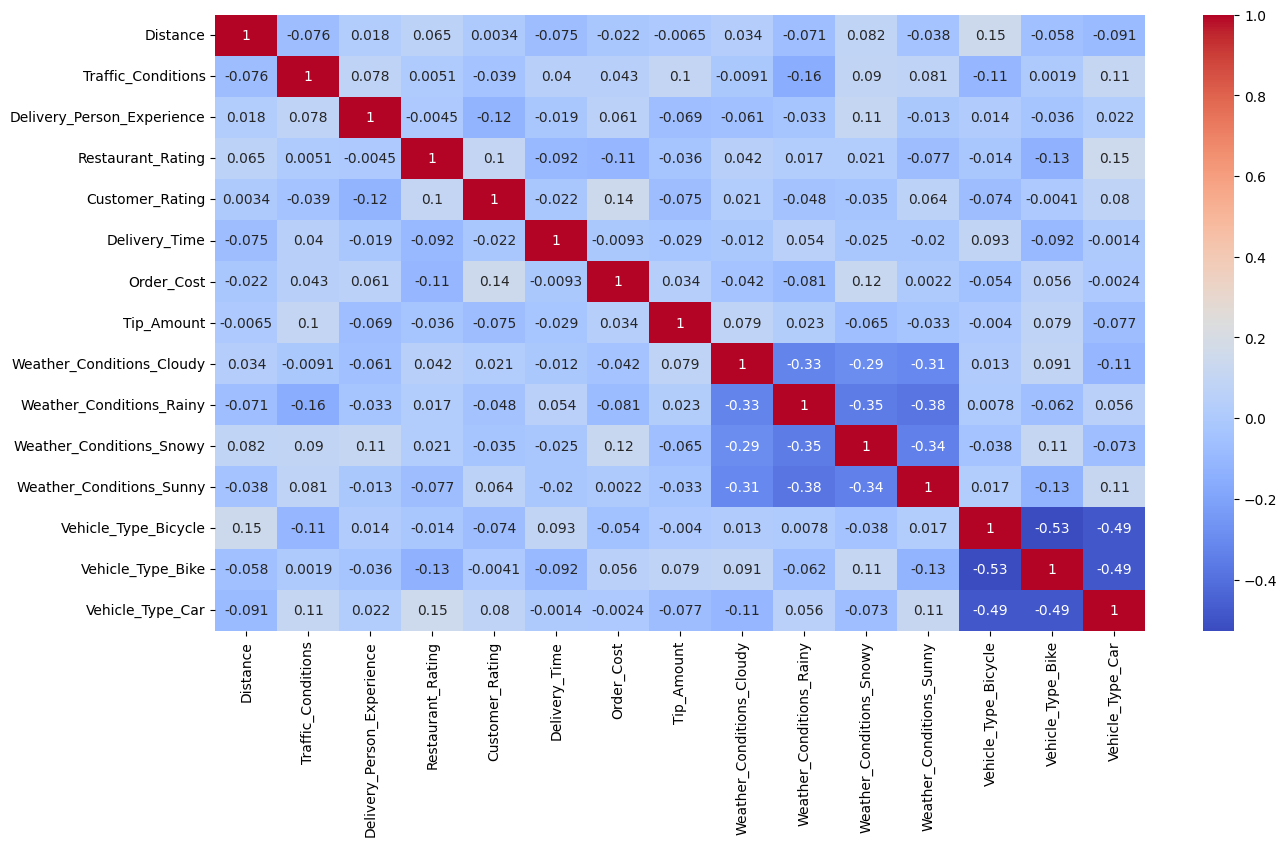

In [26]:
plt.figure(figsize=(15,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.show()

**3. Outlier Detection** :
Detect outliers in numerical features using boxplots and handle them appropriately.


***Boxplots** are used to visually detect outliers.*

In [27]:
numerical_cols = [
    "Distance",
    "Traffic_Conditions",
    "Delivery_Person_Experience",
    "Order_Priority",
    "Restaurant_Rating",
    "Customer_Rating",
    "Delivery_Time",
    "Order_Cost",
    "Tip_Amount"
]

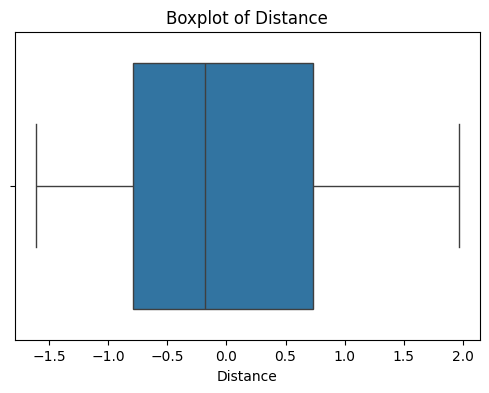

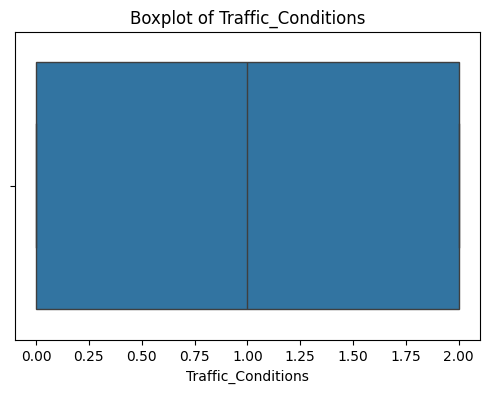

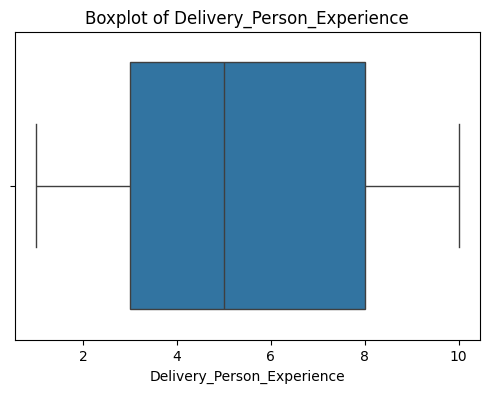

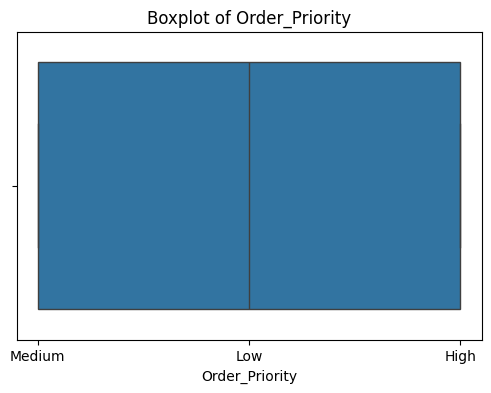

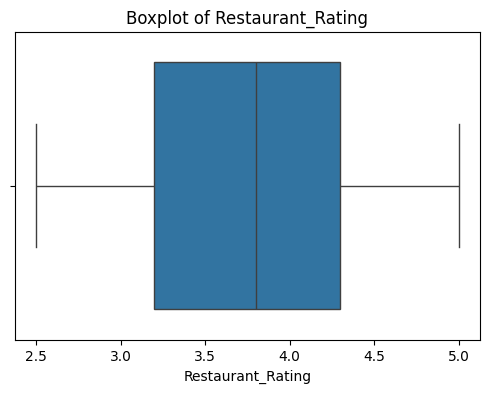

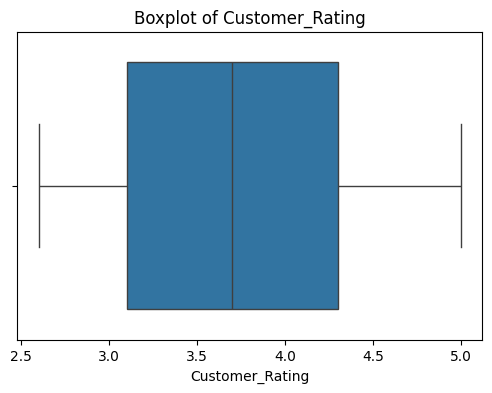

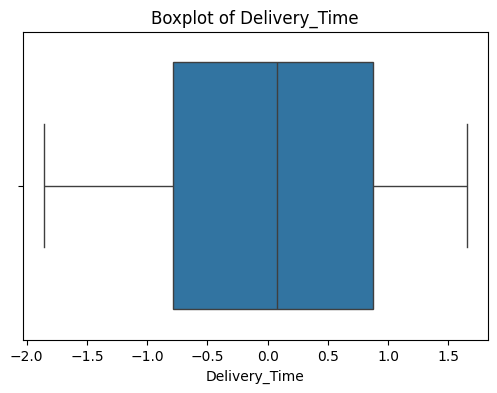

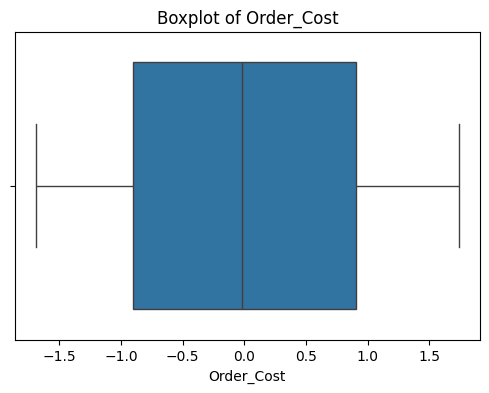

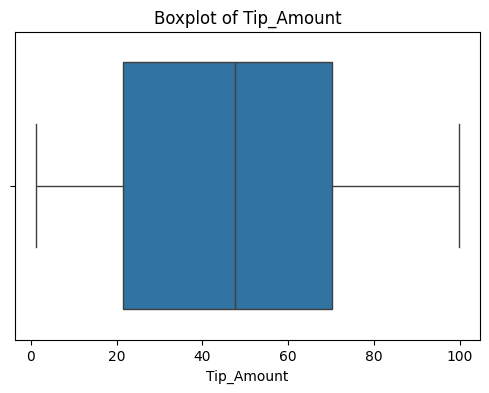

In [28]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

fair distribution

## **Step 3 - Feature Engineering**

**1. Distance Calculation** :
If the dataset doesn't contain an actual distance metric, calculate the distance between the customer and restaurant using latitudes and
longitudes (Haversine formula).

Ans : The dataset already contained a precomputed Distance feature. Therefore, additional distance calculation using the Haversine Formula was not required.


**2. Time-Based Features** :
Create new features related to the time of day, such as Rush Hour vs Non-Rush Hour, to improve predictions.


***we already one-hot coded order_time so that is is already transformed into usable features.***

In [29]:
df.columns

Index(['Order_ID', 'Customer_Location', 'Restaurant_Location', 'Distance',
       'Traffic_Conditions', 'Delivery_Person_Experience', 'Order_Priority',
       'Order_Time', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time',
       'Order_Cost', 'Tip_Amount', 'Weather_Conditions_Cloudy',
       'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Vehicle_Type_Bicycle', 'Vehicle_Type_Bike',
       'Vehicle_Type_Car'],
      dtype='object')

In [30]:
df["Order_Time"].unique()

array(['Afternoon', 'Night', 'Evening', 'Morning'], dtype=object)

In [31]:
df["Rush_Hour"] = df["Order_Time"].apply(
    lambda x: 1 if x in ["Morning", "Evening"] else 0
)

In [32]:
df[["Order_Time", "Rush_Hour"]].head(10)

,Order_Time,Rush_Hour
0,Afternoon,0
1,Night,0
2,Night,0
3,Evening,1
4,Night,0
5,Evening,1
6,Evening,1
7,Evening,1
8,Night,0
9,Afternoon,0


A new time-based feature named Rush_Hour was engineered using the one-hot encoded Order_Time categories.

# **Phase 2: Predictive Modeling**

### **Step 4 - Linear Regression Model**

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Order_Priority"] = le.fit_transform(df["Order_Priority"]) #fixed the string values

In [34]:
x = df[[
    "Distance",
    "Traffic_Conditions",
    "Order_Priority",
]]
x.head()

,Distance,Traffic_Conditions,Order_Priority
0,-1.454738,2,2
1,1.439192,2,1
2,-0.666417,2,0
3,0.335835,1,2
4,-0.700119,0,1


In [35]:
y = df["Delivery_Time"]
y.head()

,Delivery_Time
0,-1.487932
1,-0.264987
2,-0.741529
3,1.382411
4,-1.280915


**1. Train-Test Split** :
Split the dataset into training and testing sets (e.g., 80/20 split).


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


**2. Model Building** :
Use Linear Regression to predict the Delivery Time based on features like Distance, Traffic_Conditions, and
Order_Priority.

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(X_test)

In [42]:
print(y_pred[:5])

[-0.05863832 -0.01580191 -0.10429917 -0.04624307 -0.00162638]


**3. Evaluation Metrics** :
Evaluate the model using:

○ Mean Squared Error (MSE)

○ R-squared (R²)

○ Mean Absolute Error (MAE)

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [44]:
mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

In [45]:
print("MSE:", mse)

print("MAE:", mae)

print("R2 Score:", r2)

MSE: 1.0281987101443204
MAE: 0.8518511210665173
R2 Score: 0.01568023241561467


1. Mean Squared Error (MSE) : 1.0281


not extremely terrible but not very strong either.

2. Mean Absolute Error (MAE): 0.851

average prediction error ≈ 0.85 units

Since target was scaled:

predictions are somewhat far from actual values.

3. R² Score : 0.015

This is VERY low.

the model explains less than 1% of delivery time variation.

In simpler words:

selected features are not strongly predicting delivery time.

The Linear Regression model was evaluated using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared (R²) metrics. The model achieved an MSE of 1.0281 and an MAE of 0.851. The R² score was approximately 0.015, indicating that the selected features explained only a small portion of the variation in Delivery_Time. This suggests that the dataset contains weak linear relationships between the selected predictors and the target variable.


## **Step 5 - Logistic Regression Model (for Categorization)**

**1. Model Objective** :
Classify deliveries as "Fast" or "Delayed" based on binary features such as Traffic, Weather, Delivery_Person_Experience, etc



In [46]:
df["Delivery_Time"].median()

0.07662482028384994

Classification Logic:

| Delivery_Time | Delivery_Status |
| ------------- | --------------- |
| <= 0.0766     | Fast (0)        |
| > 0.0766      | Delayed (1)     |

In [47]:
df["Delivery_Status"] = df["Delivery_Time"].apply(
    lambda x: 1 if x > 0.0766 else 0
)

In [48]:
df[["Delivery_Time", "Delivery_Status"]].head(10)

,Delivery_Time,Delivery_Status
0,-1.487932,0
1,-0.264987,0
2,-0.741529,0
3,1.382411,1
4,-1.280915,0
5,-0.328503,0
6,-1.402571,0
7,-0.444110,0
8,-0.782193,0
9,0.371523,1


In [49]:
X = df[[
    "Distance",
    "Traffic_Conditions",
    "Order_Priority"
]]
X.head()

,Distance,Traffic_Conditions,Order_Priority
0,-1.454738,2,2
1,1.439192,2,1
2,-0.666417,2,0
3,0.335835,1,2
4,-0.700119,0,1


In [50]:
y = df["Delivery_Status"]
y.head()

,Delivery_Status
0,0
1,0
2,0
3,1
4,0


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


**2. Model Implementation** :
Use Logistic Regression to predict the delivery status.

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [55]:
y_pred = model.predict(X_test)

In [56]:
print(y_pred[:10])

[0 0 0 0 0 0 1 1 1 0]


**3. Evaluation Metrics** :
Evaluate using metrics such as:

○ Accuracy

○ Precision

○ Recall

○ F1-score

○ Confusion Matrix

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [58]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

In [59]:
print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

print("Confusion Matrix:\n", cm)

Accuracy: 0.625
Precision: 0.6875
Recall: 0.5238095238095238
F1 Score: 0.5945945945945946
Confusion Matrix:
 [[14  5]
 [10 11]]


Structure
|                | Predicted Fast | Predicted Delayed |
| -------------- | -------------- | ----------------- |
| Actual Fast    | 14             | 5                 |
| Actual Delayed | 10             | 11                |


The Logistic Regression model achieved an accuracy of 62.5%, indicating moderate classification performance for predicting whether deliveries were fast or delayed. The model obtained a precision score of 68.75%, showing that delayed delivery predictions were relatively reliable. The recall score of 52.38% indicated that the model correctly identified slightly more than half of the actual delayed deliveries. The confusion matrix further showed that the model performed reasonably well in distinguishing between fast and delayed deliveries despite the limited dataset size and weak feature correlations.



# **Phase 3: Reporting and Insights**

● Compare the Linear Regression and Logistic Regression models based on their performance

COMPARISION TABLE :

| Metric         | Linear Regression          | Logistic Regression           |
| -------------- | -------------------------- | ----------------------------- |
| **Goal**           | Predict exact time         | Predict fast/delayed          |
| **Main Metric**   | R² Score                   | Accuracy                      |
| **Performance**   | Weak (R² ≈ 0.015)          | Moderate (62.5%)              |
| **Usefulness**     | Limited                    | More practical                |
| **Interpretation** | Weak feature relationships | Better classification ability |


● Visualize the results using confusion matrices and ROC curves.

confusion matrices

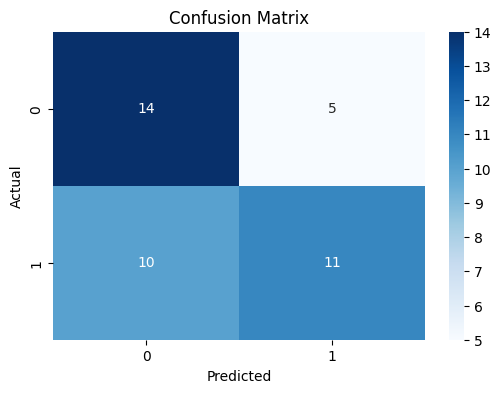

In [60]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

ROC Curve

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score

In [62]:
y_prob = model.predict_proba(X_test)[:,1]

In [63]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

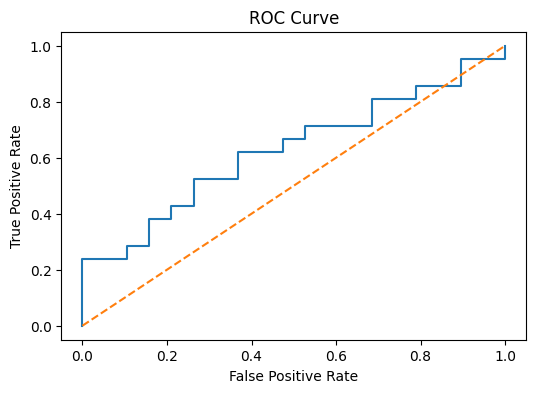

In [64]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

**Step 7 - Actionable Insights**


According to the findings from the model analysis, there are some operational areas where changes can be made. For instance, the delivery paths may be optimized for effective delivery since there are always delays attributed to lengthy transportation distance and traffic jams. Extra delivery personnel can also be hired when traffic is heavy in order to cope with large numbers of orders.